### Research Question 1:

How well do surrogate scores generalize under distributional shift (OOD)
- Can the model predict the ranking correctly?-> spearman
- Can the model predict the actual scores correct -> mse
- Are there systematic biases in OOD regions? -> report bias=mean(pred-true)

These Questions are answered by Scoring two datasets of Sequences. 
1. TFBind8:
    The dataset is split up into train data (lower 50%) to train the models and test data.
2. GB1:
    Scince the GB1 data is just wildtypes with two mutations, new sequences are produced by the Single Mutant Walker to gain data with a higher distance from the training sequences.
In both datasets the distributional shift is measured as minimum hamming distance from the training data. The higher the hamming distance is, the further away are the sequences from the training data. 

Each dataset is scored by both surrogate models: MLP and Random Forest. 


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
from assets.compute_metrics import compute_model_metrics
from assets.plot import plot_metrics_vs_hamming_distance
import metrics_tfbind8
import metrics_gb1

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### TFBind 8

In [2]:
# Check if results already exist before running metrics computation
PATH = 'results/tfbind8_sequences_scored.csv'
if os.path.exists(PATH):
    print(f"Loading existing results from {PATH}")
    df_tf_results = pd.read_csv(PATH)
else:
    print(f"No existing results found at {PATH}. Running metrics computation.")
    metrics_tfbind8.main()
    df_tf_results = pd.read_csv(PATH)

# Print stats about df_results
print("Summary of results:")
print(df_tf_results.describe())
print(df_tf_results.head(3))

Loading existing results from results/tfbind8_sequences_scored.csv
Summary of results:
       binding_scores       cluster  distance_to_seed  min_hamming_distance  \
count    64137.000000  64137.000000      64137.000000          64137.000000   
mean         0.467300     17.588568          3.092022              2.029546   
std          0.174734     13.884230          0.737235              0.722107   
min          0.000000      0.000000          0.000000              0.000000   
25%          0.339958      6.000000          3.000000              2.000000   
50%          0.444594     14.000000          3.000000              2.000000   
75%          0.570239     27.000000          4.000000              3.000000   
max          1.000000     49.000000          5.000000              4.000000   

       rf_prediction  mlp_prediction  
count   64137.000000    64137.000000  
mean        0.333135        0.345605  
std         0.032926        0.071199  
min         0.146023        0.046661  
25%   

In [5]:
# Compute model metrics
compute_model_metrics(df_tf_results, target_col = 'binding_scores', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction')


MODEL PERFORMANCE METRICS
        Model Spearman ρ    MSE   Bias Variance
Random Forest     0.3682 0.0457 0.1342   0.0011
          MLP     0.2697 0.0438 0.1217   0.0051



<Axes: title={'center': 'Mean Absolute Error vs Min Hamming Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Mean Absolute Error'>

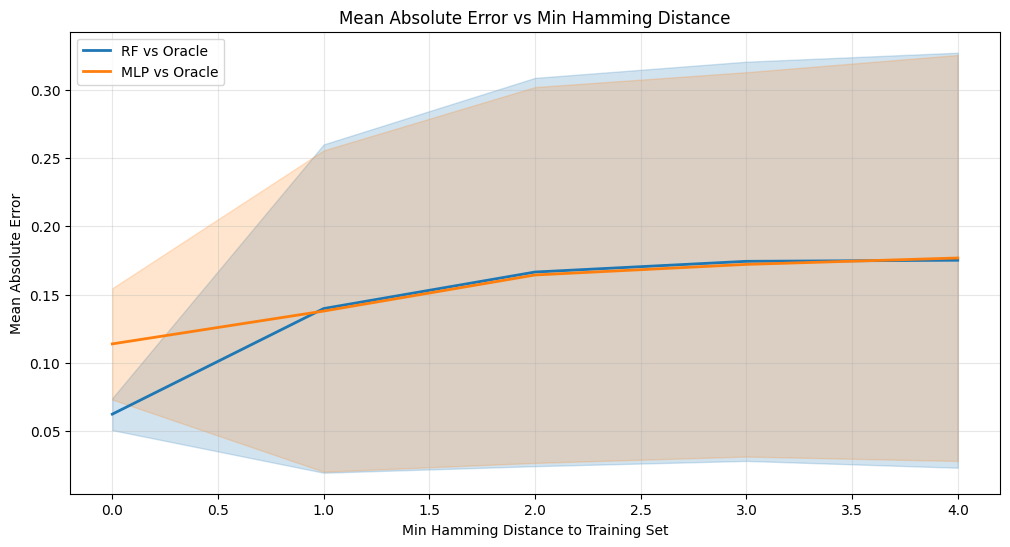

In [7]:
plot_metrics_vs_hamming_distance(df_tf_results, target_col = 'binding_scores', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction', hamming_col = 'min_hamming_distance')

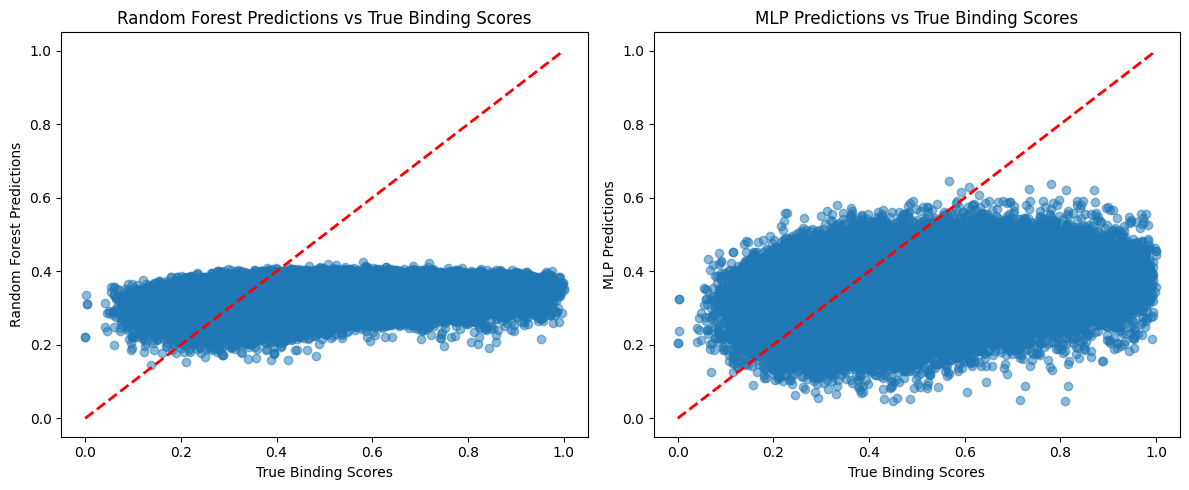

In [4]:
# Plot oracle scores against mlp and rf predictions
# Red line shows perfect predictions (y=x)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_tf_results['binding_scores'], df_tf_results['rf_prediction'], alpha=0.5)
plt.plot([df_tf_results['binding_scores'].min(), df_tf_results['binding_scores'].max()], [df_tf_results['binding_scores'].min(), df_tf_results['binding_scores'].max()], 'r--', lw=2)
plt.xlabel('True Binding Scores')
plt.ylabel('Random Forest Predictions')
plt.title('Random Forest Predictions vs True Binding Scores')
plt.subplot(1, 2, 2)
plt.scatter(df_tf_results['binding_scores'], df_tf_results['mlp_prediction'], alpha=0.5)
plt.plot([df_tf_results['binding_scores'].min(), df_tf_results['binding_scores'].max()], [df_tf_results['binding_scores'].min(), df_tf_results['binding_scores'].max()], 'r--', lw=2)
plt.xlabel('True Binding Scores')
plt.ylabel('MLP Predictions')
plt.title('MLP Predictions vs True Binding Scores')
plt.tight_layout()
plt.show()

#### GB1

In [8]:
# Check if results already exist before running metrics computation
PATH = 'results/gb1_generated_sequences_scored.csv'
if os.path.exists(PATH):
    print(f"Loading existing results from {PATH}")
    df_gb_results = pd.read_csv(PATH)
else:
    print(f"No existing results found at {PATH}. Running metrics computation.")
    metrics_gb1.main()
    df_gb_results = pd.read_csv(PATH)

# Print stats about df_results
print("Summary of results:")
print(df_gb_results.describe())
print(df_gb_results.head(3))

Loading existing results from results/gb1_generated_sequences_scored.csv
Summary of results:
       min_hamming_distance  oracle_score  rf_prediction  mlp_prediction
count          56022.000000  56022.000000   56022.000000    56022.000000
mean              10.160776     -2.819095      -6.629210       -5.756415
std                7.851438      3.068266       1.180992        2.488559
min                1.000000    -11.113106      -8.689366      -15.666929
25%                4.000000     -5.449906      -7.518721       -7.483796
50%                8.000000     -2.684820      -6.861625       -5.979722
75%               16.000000     -0.153023      -5.936491       -4.184005
max               33.000000      9.054427      -2.306809        0.323029
                                            sequence  ...  mlp_prediction
0  QYKLILNGKTLKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...  ...       -6.506698
1  QYKLILNGKTPKGETTGEAVDAATAEKKFKQYANDNGVDGEHTYDD...  ...       -6.192511
2  QYKLILNGKTPKGETTGEAVDAATA

In [9]:
compute_model_metrics(df_gb_results, target_col = 'oracle_score', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction')


MODEL PERFORMANCE METRICS
        Model Spearman ρ     MSE   Bias Variance
Random Forest     0.3293 23.0236 3.8101   1.3947
          MLP     0.6494 14.6292 2.9373   6.1928



<Axes: title={'center': 'Mean Absolute Error vs Min Hamming Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Mean Absolute Error'>

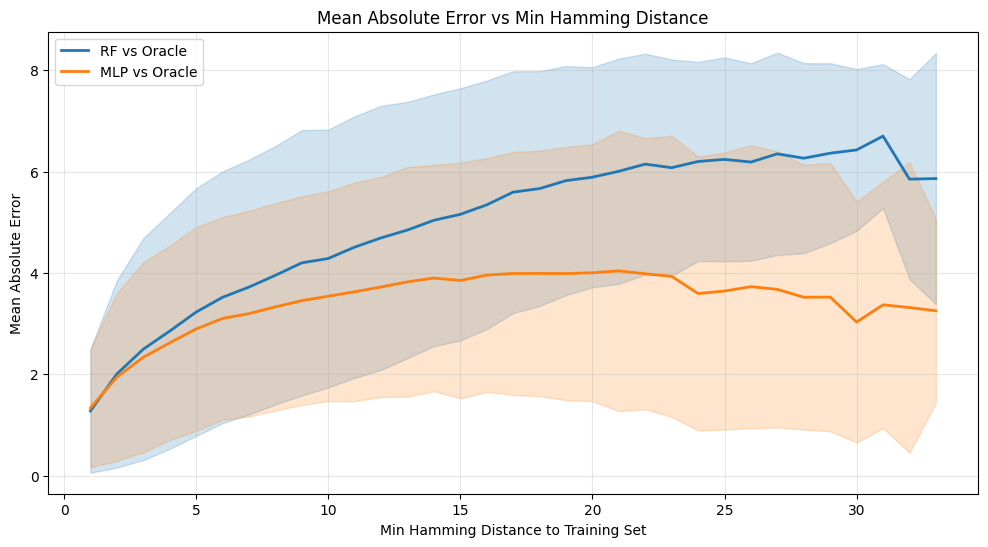

In [10]:
plot_metrics_vs_hamming_distance(df_gb_results, target_col = 'oracle_score', rf_pred_col='rf_prediction', mlp_pred_col= 'mlp_prediction', hamming_col = 'min_hamming_distance')